In [ ]:
# # 競艇予測 SVM モデル学習

# このノートブックでは、SVMを使用して競艇の着順1位を予測するモデルを学習します。

# ## データソース
# - `features/`: 各特徴量CSVファイル（1着フラグ付き）

# ## 目標
# - 1着フラグを目的変数として二値分類モデルを構築
# - モデルの性能評価と特徴量分析

In [ ]:
# 必要なライブラリをインポート
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_style("whitegrid")
plt.style.use("default")

In [ ]:
# 日本語フォント設定
matplotlib.rc("font", family="IPAexGothic")

In [ ]:
# features以下の全CSVファイルを読み込んで一つのDataFrameにする
import glob
import os

# featuresディレクトリのCSVファイルを取得
features_dir = "features"
csv_files = glob.glob(os.path.join(features_dir, "*.csv"))

# .gitignoreを除外
csv_files = [f for f in csv_files if not f.endswith(".gitignore")]

print(f"読み込み対象のCSVファイル: {len(csv_files)}個")
for file in csv_files:
    print(f"  - {os.path.basename(file)}")

# 1位フラグファイルを特定して最後に処理するために分離
target_file = None
feature_files = []

for file in csv_files:
    filename = os.path.basename(file)
    if "1着フラグ" in filename:
        target_file = file
        print(f"目的変数ファイル: {filename}")
    else:
        feature_files.append(file)
        print(f"特徴量ファイル: {filename}")

# 特徴量ファイルを読み込んでマージ
train_df = None

for file in feature_files:
    df = pd.read_csv(file, encoding="utf-8-sig")
    filename = os.path.basename(file).replace(".csv", "")
    print(f"読み込み: {filename} - Shape: {df.shape}")

    if train_df is None:
        train_df = df.copy()
    else:
        # レースIDと枠番をキーにしてマージ
        train_df = train_df.merge(df, on=["レースID", "枠番"], how="inner")
        print(f"マージ後のShape: {train_df.shape}")

# 最後に1位フラグを読み込んでマージ
if target_file:
    target_df = pd.read_csv(target_file, encoding="utf-8-sig")
    filename = os.path.basename(target_file).replace(".csv", "")
    print(f"目的変数読み込み: {filename} - Shape: {target_df.shape}")

    train_df = train_df.merge(target_df, on=["レースID", "枠番"], how="inner")
    print(f"最終マージ後のShape: {train_df.shape}")

print(f"\n=== 最終データ情報 ===")
print(f"データ形状: {train_df.shape}")
print(f"カラム一覧: {train_df.columns.tolist()}")

# データの先頭5行を表示
train_df.head()
# csvに出力
train_df.to_csv(
    os.path.join("data", "train_data_svm.csv"), index=False, encoding="utf-8-sig"
)

読み込み対象のCSVファイル: 6個
  - レース内コース別1着率差.csv
  - 1着フラグ.csv
  - レース内コース別平均スタートタイミング差.csv
  - レース内全国勝率差.csv
  - レース内級差.csv
  - レース内コース別複勝率差.csv
特徴量ファイル: レース内コース別1着率差.csv
目的変数ファイル: 1着フラグ.csv
特徴量ファイル: レース内コース別平均スタートタイミング差.csv
特徴量ファイル: レース内全国勝率差.csv
特徴量ファイル: レース内級差.csv
特徴量ファイル: レース内コース別複勝率差.csv
読み込み: レース内コース別1着率差 - Shape: (90648, 3)
読み込み: レース内コース別平均スタートタイミング差 - Shape: (90648, 3)
マージ後のShape: (90648, 4)
読み込み: レース内全国勝率差 - Shape: (90648, 3)
マージ後のShape: (90648, 5)
読み込み: レース内級差 - Shape: (90648, 3)
マージ後のShape: (90648, 6)
読み込み: レース内コース別複勝率差 - Shape: (90648, 3)
マージ後のShape: (90648, 7)
目的変数読み込み: 1着フラグ - Shape: (90648, 3)
最終マージ後のShape: (90648, 8)

=== 最終データ情報 ===
データ形状: (90648, 8)
カラム一覧: ['レースID', '枠番', 'レース内コース別1着率差', 'レース内コース別平均スタートタイミング差', 'レース内全国勝率差', 'レース内級差', 'レース内コース別複勝率差', '1着フラグ']


In [ ]:
# データの基本情報を確認
print("=== データ型情報 ===")
print(train_df.dtypes)

print("\n=== 欠損値情報 ===")
print(train_df.isnull().sum())

print("\n=== 目的変数（1着フラグ）の分布 ===")
target_counts = train_df["1着フラグ"].value_counts()
print(target_counts)
print(f"\n1着率: {target_counts[1] / len(train_df) * 100:.2f}%")

print("\n=== 基本統計量 ===")
train_df.describe()

=== データ型情報 ===
レースID                     int64
枠番                        int64
レース内コース別1着率差            float64
レース内コース別平均スタートタイミング差    float64
レース内全国勝率差               float64
レース内級差                  float64
レース内コース別複勝率差            float64
1着フラグ                     int64
dtype: object

=== 欠損値情報 ===
レースID                   0
枠番                      0
レース内コース別1着率差            0
レース内コース別平均スタートタイミング差    0
レース内全国勝率差               0
レース内級差                  0
レース内コース別複勝率差            0
1着フラグ                   0
dtype: int64

=== 目的変数（1着フラグ）の分布 ===
1着フラグ
0    75713
1    14935
Name: count, dtype: int64

1着率: 16.48%

=== 基本統計量 ===


,レースID,枠番,レース内コース別1着率差,レース内コース別平均スタートタイミング差,レース内全国勝率差,レース内級差,レース内コース別複勝率差,1着フラグ
count,9.064800e+04,90648.000000,9.064800e+04,90648.000000,90648.000000,90648.000000,90648.000000,90648.000000
mean,2.025062e+11,3.500000,6.949960e-07,-0.000003,0.000002,-0.000015,-0.000002,0.164758
std,8.336181e+05,1.707835,2.041682e-01,0.035266,1.134732,2.086263,0.243259,0.370964
min,2.025050e+11,1.000000,-3.582000e-01,-0.200000,-5.317000,-5.833000,-0.542000,0.000000
25%,2.025052e+11,2.000000,-1.319000e-01,-0.018000,-0.638000,-1.333000,-0.187000,0.000000
50%,2.025062e+11,3.500000,-6.800000e-02,0.000000,0.045000,-0.500000,-0.044000,0.000000
75%,2.025071e+11,5.000000,4.150000e-02,0.020000,0.740000,0.667000,0.137000,0.000000
max,2.025073e+11,6.000000,8.223000e-01,0.233000,4.237000,5.500000,0.800000,1.000000


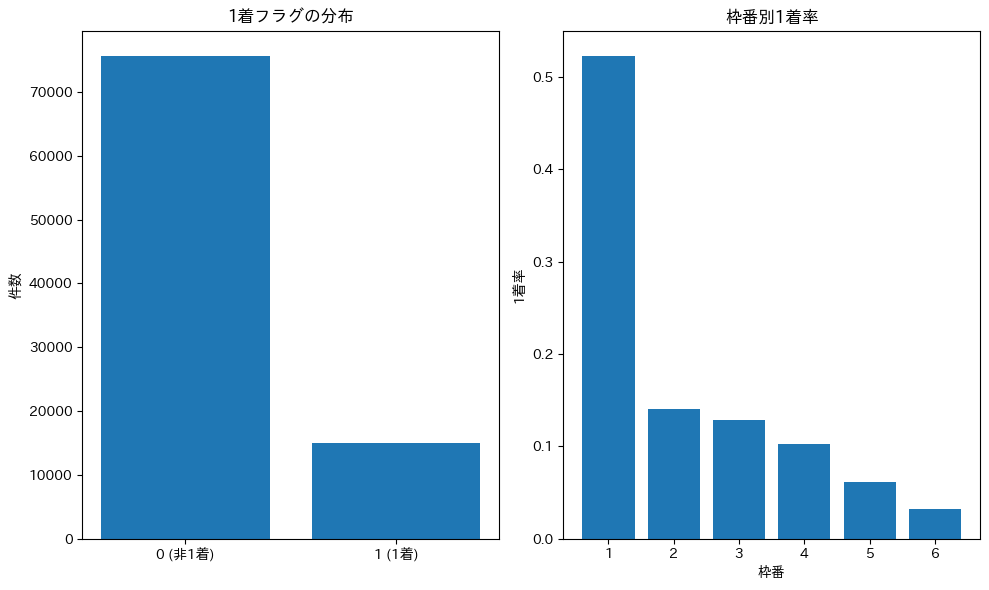

In [ ]:
# 目的変数の分布を可視化
plt.figure(figsize=(10, 6))

# 1着フラグの分布
plt.subplot(1, 2, 1)
target_counts = train_df["1着フラグ"].value_counts()
plt.bar(["0 (非1着)", "1 (1着)"], target_counts.values)
plt.title("1着フラグの分布")
plt.ylabel("件数")

# 枠番別の1着率
plt.subplot(1, 2, 2)
win_rate_by_frame = train_df.groupby("枠番")["1着フラグ"].mean()
plt.bar(win_rate_by_frame.index, win_rate_by_frame.values)
plt.title("枠番別1着率")
plt.xlabel("枠番")
plt.ylabel("1着率")

plt.tight_layout()
plt.show()

In [ ]:
win_rate_by_frame

枠番
1    0.522968
2    0.140588
3    0.128674
4    0.102859
5    0.061424
6    0.032036
Name: 1着フラグ, dtype: float64

In [ ]:
# 不要なレースIDを削除
train_df = train_df.drop(columns=["レースID"])

In [ ]:
# 特徴量と目的変数を分離
X = train_df.drop(columns=["1着フラグ"])
y = train_df["1着フラグ"]

print(f"特徴量の形状: {X.shape}")
print(f"目的変数の形状: {y.shape}")
print(f"特徴量一覧: {X.columns.tolist()}")

# 学習・テスト用に分割（stratifyで1着フラグの比率を保持）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n学習データ: {X_train.shape}")
print(f"テストデータ: {X_test.shape}")
print(f"学習データの1着率: {y_train.mean():.3f}")
print(f"テストデータの1着率: {y_test.mean():.3f}")

特徴量の形状: (90648, 6)
目的変数の形状: (90648,)
特徴量一覧: ['枠番', 'レース内コース別1着率差', 'レース内コース別平均スタートタイミング差', 'レース内全国勝率差', 'レース内級差', 'レース内コース別複勝率差']

学習データ: (72518, 6)
テストデータ: (18130, 6)
学習データの1着率: 0.165
テストデータの1着率: 0.165


In [ ]:
# SVMは特徴量のスケールに敏感なので標準化を実施
print("=== 特徴量の標準化 ===")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"標準化前の特徴量範囲（学習データ）:")
print(f"  最小値: {X_train.min().min():.3f}")
print(f"  最大値: {X_train.max().max():.3f}")

print(f"\n標準化後の特徴量範囲（学習データ）:")
print(f"  最小値: {X_train_scaled.min():.3f}")
print(f"  最大値: {X_train_scaled.max():.3f}")
print(f"  平均値: {X_train_scaled.mean():.3f}")
print(f"  標準偏差: {X_train_scaled.std():.3f}")

=== 特徴量の標準化 ===
標準化前の特徴量範囲（学習データ）:
  最小値: -5.833
  最大値: 6.000

標準化後の特徴量範囲（学習データ）:
  最小値: -5.535
  最大値: 6.611
  平均値: -0.000
  標準偏差: 1.000


In [ ]:
# SVMのハイパーパラメータをグリッドサーチで最適化
print("=== SVMハイパーパラメータ最適化開始 ===")

# パラメータグリッド（計算時間を考慮して範囲を制限）
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto", 0.001, 0.01],
    "kernel": ["rbf", "linear"],
}

# グリッドサーチの実行
svm_model = SVC(random_state=42, probability=True)  # probability=Trueで確率出力を有効化
grid_search = GridSearchCV(
    svm_model,
    param_grid,
    cv=3,  # 3-fold cross validation
    scoring="roc_auc",  # AUCで評価
    n_jobs=-1,  # 並列処理
    verbose=1,
)

# データサンプルサイズが大きい場合は一部をサンプリング（計算時間短縮）
sample_size = min(5000, len(X_train_scaled))
if sample_size < len(X_train_scaled):
    print(f"計算時間短縮のため{sample_size}件をサンプリングしてパラメータ最適化を実行")
    sample_idx = np.random.choice(len(X_train_scaled), sample_size, replace=False)
    X_sample = X_train_scaled[sample_idx]
    y_sample = y_train.iloc[sample_idx]
else:
    X_sample = X_train_scaled
    y_sample = y_train

grid_search.fit(X_sample, y_sample)

print("=== 最適パラメータ ===")
print(f"最適パラメータ: {grid_search.best_params_}")
print(f"最適スコア (CV-AUC): {grid_search.best_score_:.4f}")

=== SVMハイパーパラメータ最適化開始 ===
計算時間短縮のため5000件をサンプリングしてパラメータ最適化を実行
Fitting 3 folds for each of 24 candidates, totalling 72 fits
=== 最適パラメータ ===
最適パラメータ: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
最適スコア (CV-AUC): 0.8195


In [ ]:
# 最適パラメータでモデルを学習
print("=== SVM最終モデル学習開始 ===")
best_model = grid_search.best_estimator_

# 全学習データで再学習
best_model.fit(X_train_scaled, y_train)
print("=== 学習完了 ===")

=== SVM最終モデル学習開始 ===
=== 学習完了 ===


In [ ]:
# 予測実行
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]  # 1着の確率
y_pred = (y_pred_proba > 0.4).astype(int)

# 評価指標の計算
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print("=== モデル評価結果 ===")
print(f"精度 (Accuracy): {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")

print("\n=== 分類レポート ===")
print(classification_report(y_test, y_pred, target_names=["非1着", "1着"]))

=== モデル評価結果 ===
精度 (Accuracy): 0.8614
AUC Score: 0.8142

=== 分類レポート ===
              precision    recall  f1-score   support

         非1着       0.89      0.95      0.92     15143
          1着       0.61      0.43      0.50      2987

    accuracy                           0.86     18130
   macro avg       0.75      0.69      0.71     18130
weighted avg       0.85      0.86      0.85     18130



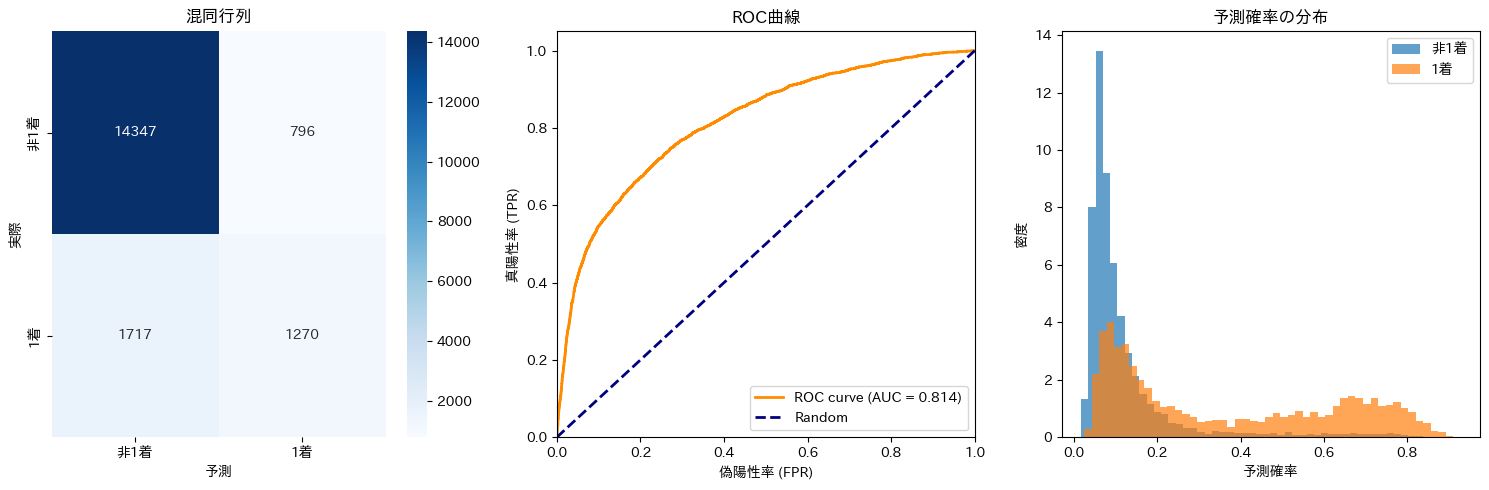

In [ ]:
# 混同行列とROC曲線の可視化
plt.figure(figsize=(15, 5))

# 混同行列
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["非1着", "1着"],
    yticklabels=["非1着", "1着"],
)
plt.title("混同行列")
plt.ylabel("実際")
plt.xlabel("予測")

# ROC曲線
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("偽陽性率 (FPR)")
plt.ylabel("真陽性率 (TPR)")
plt.title("ROC曲線")
plt.legend(loc="lower right")

# 予測確率の分布
plt.subplot(1, 3, 3)
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label="非1着", density=True)
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label="1着", density=True)
plt.xlabel("予測確率")
plt.ylabel("密度")
plt.title("予測確率の分布")
plt.legend()

plt.tight_layout()
plt.show()

=== 特徴量重要度（線形SVM係数の絶対値） ===
                feature  importance
1          レース内コース別1着率差    0.692469
5          レース内コース別複勝率差    0.167651
3             レース内全国勝率差    0.091540
0                    枠番    0.080223
4                レース内級差    0.067382
2  レース内コース別平均スタートタイミング差    0.021117


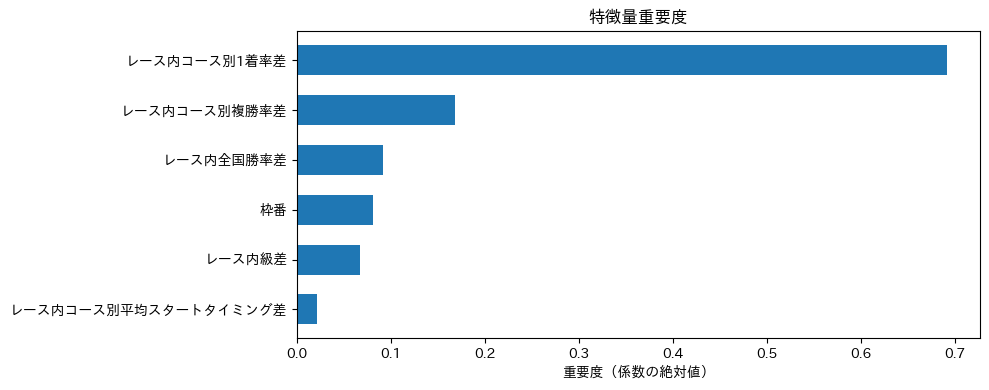

In [ ]:
# SVMは線形カーネルの場合のみ特徴量重要度が取得可能
if best_model.kernel == "linear":
    # 線形SVMの係数を特徴量重要度として使用
    feature_importance = pd.DataFrame(
        {
            "feature": X.columns,
            "importance": np.abs(best_model.coef_[0]),  # 絶対値を使用
        }
    ).sort_values("importance", ascending=False)

    print("=== 特徴量重要度（線形SVM係数の絶対値） ===")
    print(feature_importance)

    # 特徴量重要度の可視化
    plt.figure(figsize=(10, 4))
    plt.barh(
        range(len(feature_importance)), feature_importance["importance"], height=0.6
    )
    plt.yticks(range(len(feature_importance)), feature_importance["feature"])
    plt.xlabel("重要度（係数の絶対値）")
    plt.title("特徴量重要度")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"=== 特徴量重要度 ===")
    print(f"使用カーネル: {best_model.kernel}")
    print("非線形カーネル（RBFなど）では直接的な特徴量重要度は取得できません。")

    # サポートベクター数を表示
    print(f"サポートベクター数: {best_model.n_support_}")
    print(f"総サポートベクター数: {sum(best_model.n_support_)}")

=== 枠番別分析 ===
      総数  実際1着数   実際1着率  平均予測確率  予測1着数   予測1着率
枠番                                            
1   2959   1568  0.5299  0.5148   2029  0.6857
2   3039    425  0.1398  0.1234     21  0.0069
3   3094    397  0.1283  0.1133      9  0.0029
4   2947    307  0.1042  0.0983      5  0.0017
5   3032    190  0.0627  0.0780      1  0.0003
6   3059    100  0.0327  0.0643      1  0.0003


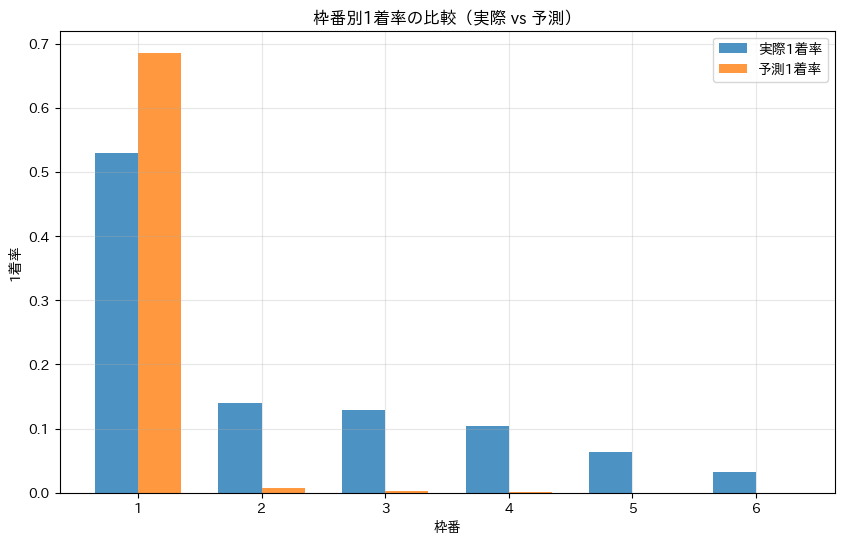

In [ ]:
# 枠番別の予測精度分析
test_results = X_test.copy()
test_results["実際"] = y_test
test_results["予測確率"] = y_pred_proba
test_results["予測"] = y_pred

# 枠番別の統計
frame_stats = (
    test_results.groupby("枠番")
    .agg(
        {"実際": ["count", "sum", "mean"], "予測確率": "mean", "予測": ["sum", "mean"]}
    )
    .round(4)
)

frame_stats.columns = [
    "総数",
    "実際1着数",
    "実際1着率",
    "平均予測確率",
    "予測1着数",
    "予測1着率",
]
print("=== 枠番別分析 ===")
print(frame_stats)

# 枠番別1着率の比較（実際 vs 予測）
plt.figure(figsize=(10, 6))
x = frame_stats.index
width = 0.35

plt.bar(x - width / 2, frame_stats["実際1着率"], width, label="実際1着率", alpha=0.8)
plt.bar(x + width / 2, frame_stats["予測1着率"], width, label="予測1着率", alpha=0.8)

plt.xlabel("枠番")
plt.ylabel("1着率")
plt.title("枠番別1着率の比較（実際 vs 予測）")
plt.legend()
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# モデルの保存
# SVMモデルと標準化器を一緒に保存
model_data = {
    "model": best_model,
    "scaler": scaler,
    "feature_names": X.columns.tolist(),
}

joblib.dump(model_data, "model/svm_model.pkl")
print("=== モデル保存完了 ===")
print("保存先: model/svm_model.pkl")

# 学習結果のまとめ
print("\n=== 学習結果まとめ ===")
print(f"使用データ数: {len(train_df):,} レコード")
print(f"特徴量数: {len(X.columns)} 個")
print(f"学習データ: {len(X_train):,} レコード")
print(f"テストデータ: {len(X_test):,} レコード")
print(f"最終精度: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"最適パラメータ: {grid_search.best_params_}")
print(f"サポートベクター数: {sum(best_model.n_support_)}")

# 予測例
print("\n=== 予測例（テストデータから5件）===")
sample_indices = np.random.choice(len(X_test), 5, replace=False)
for i, idx in enumerate(sample_indices):
    actual = y_test.iloc[idx]
    prob = y_pred_proba[idx]
    pred = y_pred[idx]
    frame = X_test.iloc[idx]["枠番"]
    print(f"例{i+1}: 枠番{frame}, 実際={actual}, 予測確率={prob:.3f}, 予測={pred}")

=== モデル保存完了 ===
保存先: model/svm_model.pkl

=== 学習結果まとめ ===
使用データ数: 90,648 レコード
特徴量数: 6 個
学習データ: 72,518 レコード
テストデータ: 18,130 レコード
最終精度: 0.8614
AUC Score: 0.8142
最適パラメータ: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
サポートベクター数: 23430

=== 予測例（テストデータから5件）===
例1: 枠番1.0, 実際=1, 予測確率=0.448, 予測=1
例2: 枠番6.0, 実際=0, 予測確率=0.062, 予測=0
例3: 枠番6.0, 実際=0, 予測確率=0.083, 予測=0
例4: 枠番5.0, 実際=0, 予測確率=0.066, 予測=0
例5: 枠番5.0, 実際=0, 予測確率=0.062, 予測=0
